Using device: cuda
Epoch 50, Loss: 0.732660710811615
Epoch 100, Loss: 0.17454379796981812
Epoch 150, Loss: -1.5439034700393677
Epoch 200, Loss: -0.259268581867218
Epoch 250, Loss: -1.270469307899475
Epoch 300, Loss: -0.8290305733680725
Epoch 350, Loss: -1.651006817817688
Epoch 400, Loss: -2.623760938644409
Epoch 450, Loss: -1.5530215501785278
Epoch 500, Loss: -1.2412705421447754
Final samples shape: (200000, 6)
Final data_tensor shape: torch.Size([70000, 7])
Generated 200000 valid samples.


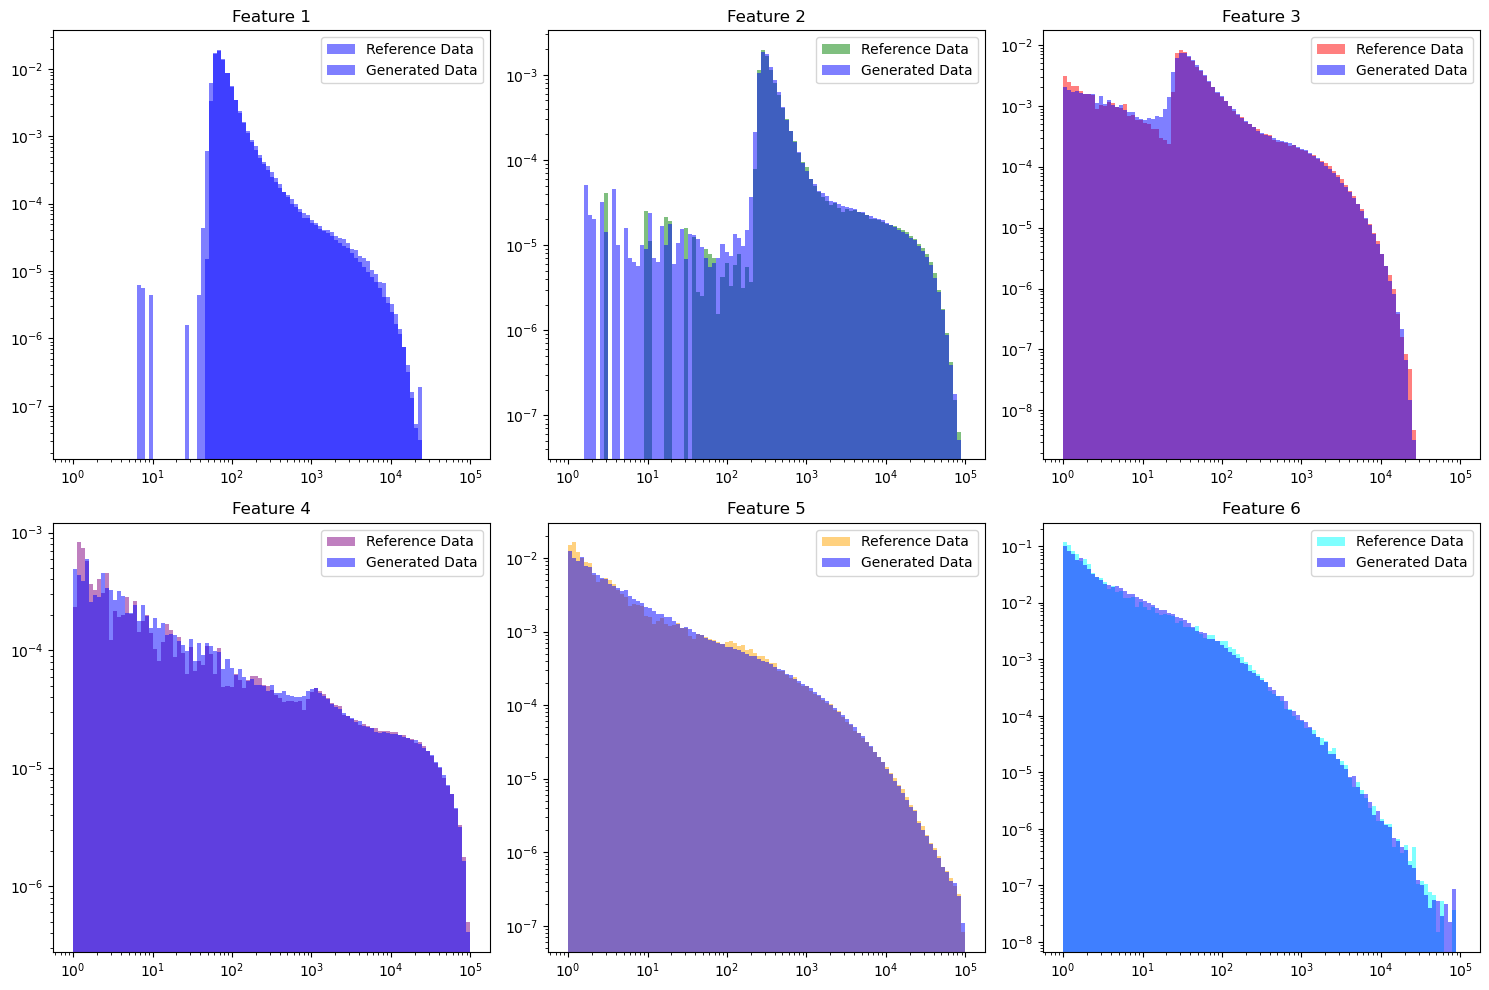

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms import MaskedPiecewiseRationalQuadraticAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)


def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

start_time = time.time()

# load and preprocess data
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

# combine energy & layers
data = np.hstack((energy.reshape(-1, 1), E_layers))

# replace inf with NaN for filterning
data[np.isinf(data)] = np.nan
# remove rows with NaN values
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

# convert to tensor
data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

# normalize and logit transform todo: f einc PREP1
data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

# debug
if torch.isnan(data_tensor).any() or torch.isinf(data_tensor).any():
    raise ValueError("Data tensor contains NaN or Inf values after transformations.")

# remove nan and inf
mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

# normalize to zero mean and unit variance (?)todo: einc PREP2
data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

# split the data tensor into context feature and training features
context_feature = data_tensor[:, 0].unsqueeze(1)  # context
input_features = data_tensor[:, 1:]  #layer features

# define flow model
num_layers = 5 #todo:  6-10
base_distribution = StandardNormal(shape=[input_features.shape[1]])  # shape matches input featurs (excl. context)
transforms = []

"""
for _ in range(num_layers):
    #permutation to shuffle features
    transforms.append(ReversePermutation(features=input_features.shape[1]))
    # Add the MaskedAffineAutoregressiveTransform with context features #transforms.MaskedPiecewiseRationalQuadraticAutoregressiveTransform statt maskedaffineautoreg.. 
    transforms.append(MaskedAffineAutoregressiveTransform(
        features=input_features.shape[1],  # exclude the context feature (corr?)
        hidden_features=64,
        context_features=1  # context is one feature (first column) (corr?)
    ))
    
"""

for _ in range(num_layers):
    transforms.append(ReversePermutation(features=input_features.shape[1]))

    transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=input_features.shape[1],
        hidden_features=64,
        context_features=1,
        num_bins=10,
        tail_bound=20.0,
        num_blocks=2, 
        use_residual_blocks=True,
        tails="linear"
    ))




"""
for _ in range(num_layers):
    # Reverse permutation to improve expressiveness
    transforms.append(ReversePermutation(features=input_features.shape[1]))

    # Replace MaskedAffineAutoregressiveTransform with MaskedPiecewiseRationalQuadraticAutoregressiveTransform
    transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=input_features.shape[1],  # Number of input features
        hidden_features=64,  # Hidden layer size
        context_features=1,  # Context feature (first column)
        num_bins=10,  # Number of bins for piecewise function
        tail_bound=20.0  # Defines range beyond which transformation is linear
    ))
"""
    
    
    
    
"""
print(f"Min input value: {input_features.min()}, Max input value: {input_features.max()}")

max_val = max(abs(batch_inputs.min().item()), abs(batch_inputs.max().item()))
tail_bound = max_val + 2  # Add some margin
print(f"Min batch input at runtime: {batch_inputs.min().item()}, Max batch input at runtime: {batch_inputs.max().item()}")
print(f"Min batch context: {batch_context.min().item()}, Max batch context: {batch_context.max().item()}")

if torch.isnan(batch_inputs).any() or torch.isinf(batch_inputs).any():
    print("Error: batch_inputs contains NaN or Inf values!")
    
if torch.isnan(batch_context).any() or torch.isinf(batch_context).any():
    print("Error: batch_context contains NaN or Inf values!")
"""

"""
for _ in range(num_layers):
    # Print before transform
    print(f"Before transform: Min batch input: {batch_inputs.min().item()}, Max batch input: {batch_inputs.max().item()}")
    
    transforms.append(ReversePermutation(features=input_features.shape[1]))  # Might be modifying values
    
    # Print after permutation (check if values change)
    print(f"After permutation: Min batch input: {batch_inputs.min().item()}, Max batch input: {batch_inputs.max().item()}")

    transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=input_features.shape[1],
        hidden_features=64,
        context_features=1,
        tail_bound=tail_bound
    ))
    
    # Print after RQ-NSF Transform (check again)
    print(f"After NSF Transform: Min batch input: {batch_inputs.min().item()}, Max batch input: {batch_inputs.max().item()}")
"""
"""
for _ in range(num_layers):
    # Print before transform
    print(f"Before transform: Min batch input: {batch_inputs.min().item()}, Max batch input: {batch_inputs.max().item()}")
    
    transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=input_features.shape[1],
        hidden_features=64,
        context_features=1,
        tail_bound=tail_bound,
        num_bins=10,  # Reduce to 5 if needed
        min_bin_width=1e-3,  # Ensure bins are large enough
        min_bin_height=1e-3,
        min_derivative=1e-3
    ))

"""
transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

# train the flow model
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500 #orig 500, nur zu testzwecken kleiner gesetzt
batch_size = 256
best_loss = float('inf')

#TODO: torch data set/ dataloader - from torch. utils. data import dataloader
# Initialize best model path
best_model_path = "best_flow_model.pth"
for epoch in range(num_epochs):
    # shuffle data
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]

    # split data into context and input features
    context_feature = data_tensor[:, 0].unsqueeze(1)  # 1. spalte
    input_features = data_tensor[:, 1:]  # remaining columns

    for i in range(0, len(input_features), batch_size):
        # create batches for input and context
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]

        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
            
        # Update best model
       # if loss.item() < best_loss:
          #  best_loss = loss.item()
           # torch.save(flow.state_dict(), best_model_path)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

        
#flow.load_state_dict(torch.load(best_model_path, weights_only=True))
import torch.nn.functional as F

# generate samples
n_samples = len(data_tensor)
n_samples = 200000
batch_size = 1000
all_samples = []

# Preprocess Einc using the same steps as the training data (corr?)
Einc_gen = torch.rand((n_samples,1)).to(device) *99+1 # todo: separat speichern
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]  # standardize



# context is expanded for each batch
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        current_batch_size = min(batch_size, n_samples - i)  #last batch otherwise prod. error
       # batch_context = Einc.repeat(current_batch_size, 1)
        #n split um batches mit einc
        batch_context = Einc_gen[i:i+batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()

        all_samples.append(samples_batch)

# since all samples now same size -> cat
samples = torch.cat(all_samples, dim=0)#100000,6


samples = samples *data_std[1:].cpu()+ data_mean[1:].cpu() 
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()
   
# Final adjustment if needed
print(f"Final samples shape: {samples.shape}")
print(f"Final data_tensor shape: {data_tensor.shape}")
print(f"Generated {len(samples)} valid samples.")

# histogramme
#num_features = data.shape[1] 
#fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
#axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
# ensure samples are valid before plotting
#if torch.isnan(samples).any() or torch.isinf(samples).any():
 #   raise ValueError("Samples contain NaN or Inf values before plotting.")

# exclude the context feature (first column of data)
# histogramme
num_features = data.shape[1] - 1
fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features): 
    #bins = 500 if len(data[:, i+1]) > 500 else len(data[:, i+1])  
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],  #exclude context feature
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=colors[i % len(colors)],  
        density=True,
        log=True
    )
    axs[i].hist(
        samples[:, i],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color='blue',  
        density=True,
        log=True
    )
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")  

for j in range(len(axs)):
    if j >= num_features:
        axs[j].axis('off')

plt.tight_layout()
plt.show()

In [2]:
#CLASSIFIER
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

ALPHA = 1e-6

import numpy as np

def logit(x):
    return np.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = np.clip(ALPHA + (1. - 2. * ALPHA) * x, 1e-6, 1 - 1e-6)
    return logit(local_x)


###changes
real_data = data_tensor.cpu().numpy()
Einc_gen_numpy = Einc_gen.cpu().numpy().reshape(-1, 1) 
samples_with_einc = np.hstack((Einc_gen_numpy, samples))  
generated_data = samples_with_einc


###changes end


#real_data = data_tensor[:, 1:].cpu().numpy()
#generated_data = samples

#preprocess real_data and generated_data
#PREP1
print(type(real_data))
print(type(generated_data))
"""

data_max1 = real_data.max(axis=0)  # Correct for NumPy
real_data = real_data / data_max1
real_data = logit_trafo(real_data)
# PREP2
data_mean1 = real_data.mean(axis=0)
data_std1 = real_data.std(axis=0)
real_data = (real_data - data_mean1) / data_std1

#PREP1
data_max2 = generated_data.max(axis=0)
generated_data = generated_data / data_max2
generated_data = logit_trafo(generated_data)
# PREP2
data_mean2 = generated_data.mean(axis=0)
data_std2 = generated_data.std(axis=0)
generated_data = (generated_data - data_mean2) / data_std2
"""

# Compute max, mean, std based on **combined** dataset
combined = np.vstack((real_data, generated_data))

data_max = combined.max(axis=0)
data_mean = combined.mean(axis=0)
data_std = combined.std(axis=0)

# Apply same transformations to both datasets
real_data = real_data / data_max
generated_data = generated_data / data_max

real_data = logit_trafo(real_data)
generated_data = logit_trafo(generated_data)

real_data = (real_data - data_mean) / data_std
generated_data = (generated_data - data_mean) / data_std

#changes end here

# Create labels
smallest_size = min(len(real_data), len(generated_data))

# Randomly select smallest_size indices
real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

# Select only those samples
real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

# combining of real and KDE gen data
#combined_data = np.vstack((real_data[:, 1:], generated_data))
combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.01)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.9f} Acc: {:.9f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and abs(epoch_acc - 0.5) < abs(best_acc - 0.5):
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:9f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []
    all_preds_auc = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            preds_auc = outputs
            all_preds_auc.append(preds_auc.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds_auc = np.concatenate(all_preds_auc)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)
    print('Accuracy: {:.9f}, AUC (area under roc curve): {:.9f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)

end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Final real data shape: (70000, 7)
Final gen shape: (70000, 7)
Epoch number 0/24
----------
train Loss: 0.693968181 Acc: 0.501107143
val Loss: 0.693125666 Acc: 0.503392857
Epoch number 1/24
----------
train Loss: 0.693260647 Acc: 0.501678571
val Loss: 0.693227893 Acc: 0.498857143
Epoch number 2/24
----------
train Loss: 0.693267300 Acc: 0.501053571
val Loss: 0.693163085 Acc: 0.502071429
Epoch number 3/24
----------
train Loss: 0.693256244 Acc: 0.498535714
val Loss: 0.693188066 Acc: 0.500464286
Epoch number 4/24
----------
train Loss: 0.693231708 Acc: 0.500857143
val Loss: 0.693174810 Acc: 0.501785714
Epoch number 5/24
----------
train Loss: 0.693236573 Acc: 0.501250000
val Loss: 0.693125196 Acc: 0.499250000
Epoch number 6/24
----------
train Loss: 0.693205096 Acc: 0.501741071
val Loss: 0.693072723 Acc: 0.512821429
Epoch number 7/24
----------
train Loss: 0.693187840 Acc: 0.503044643
val Loss: 0.692965737 Acc: 0.499678571
Epoch number 8/24
